In [1]:
# Regression with statsmodel in python

**Regression** lets you predict the values of a response variable from known values of explanatory variables.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols

climate_df = pd.read_csv('Data/climate_change.csv')
print(climate_df.head())

   Year  Month    MEI     CO2      CH4      N2O   CFC-11   CFC-12        TSI  \
0  1983      5  2.556  345.96  1638.59  303.677  191.324  350.113  1366.1024   
1  1983      6  2.167  345.52  1633.71  303.746  192.057  351.848  1366.1208   
2  1983      7  1.741  344.15  1633.22  303.795  192.818  353.725  1366.2850   
3  1983      8  1.130  342.25  1631.35  303.839  193.602  355.633  1366.4202   
4  1983      9  0.428  340.17  1648.40  303.901  194.392  357.465  1366.2335   

   Aerosols   Temp  
0    0.0863  0.109  
1    0.0794  0.118  
2    0.0731  0.137  
3    0.0673  0.176  
4    0.0619  0.149  


<Axes: xlabel='Temp', ylabel='CO2'>

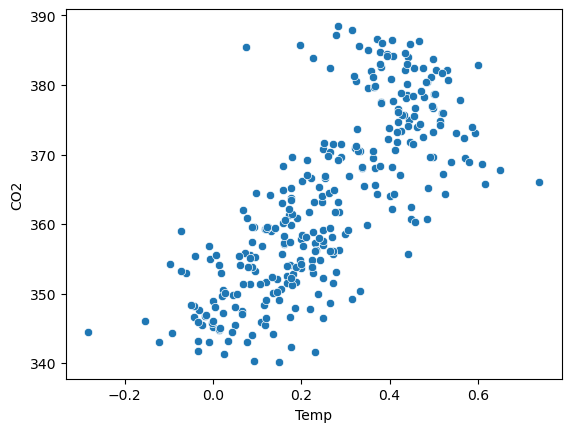

In [3]:
# Draw the scatter plot
sns.scatterplot(x="Temp",
                y="CO2",
                data=climate_df)

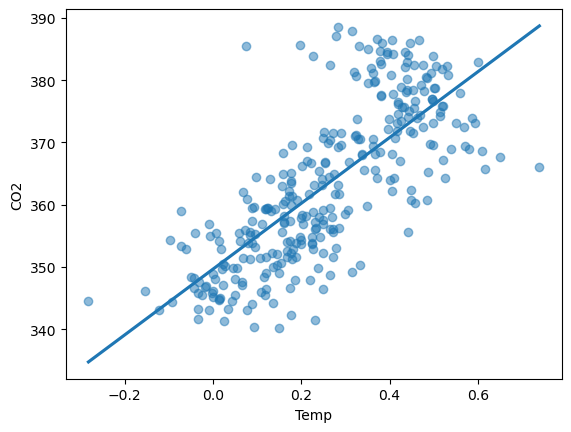

In [4]:
# Draw a trend line on the scatter plot of temp vs. co2
sns.regplot(x='Temp',
         y='CO2',
         data=climate_df,
         ci=None,
         scatter_kws={'alpha': 0.5})

# Show the plot
plt.show()

Linear regression models always fit a straight line to the data. Straight lines are defined by two properties: their intercept and their slope. The slope is the rate of change in the y direction divided by the rate of change in the x direction.

In [5]:
# Create the model object
mdl_temp_vs_co2 = ols('Temp ~ CO2', data=climate_df)

# Fit the model
mdl_temp_vs_co2 = mdl_temp_vs_co2.fit()

# Print the parameters of the fitted model
print(mdl_temp_vs_co2.params)

#Predicted Temp = -3.593140 + 0.010599 × CO2

Intercept   -3.593140
CO2          0.010599
dtype: float64


CO2 = 0.010599 — this is the slope: for every 1-unit increase in CO2, predicted temperature increases by about 0.0106 units. Since it's positive, it confirms the expected relationship: higher CO2 is associated with higher temperature. 
Intercept = -3.593140 — the predicted temperature when CO2 = 0.

With temperature as the response and CO2 as the predictor, the fitted line is temp = -3.593140 + 0.010599 × CO2, meaning each 1 ppm rise in atmospheric CO2 is associated with roughly a 0.0106°C increase in temperature — or about 1.06°C per 100 ppm — a small but physically sensible positive slope that lines up with the greenhouse-effect mechanism behind observed global warming trends; the intercept of -3.59°C is just the mathematical y-intercept (predicted temp when CO2 = 0) and isn't meaningful on its own, since CO2 has never been anywhere near zero in any observed record. 

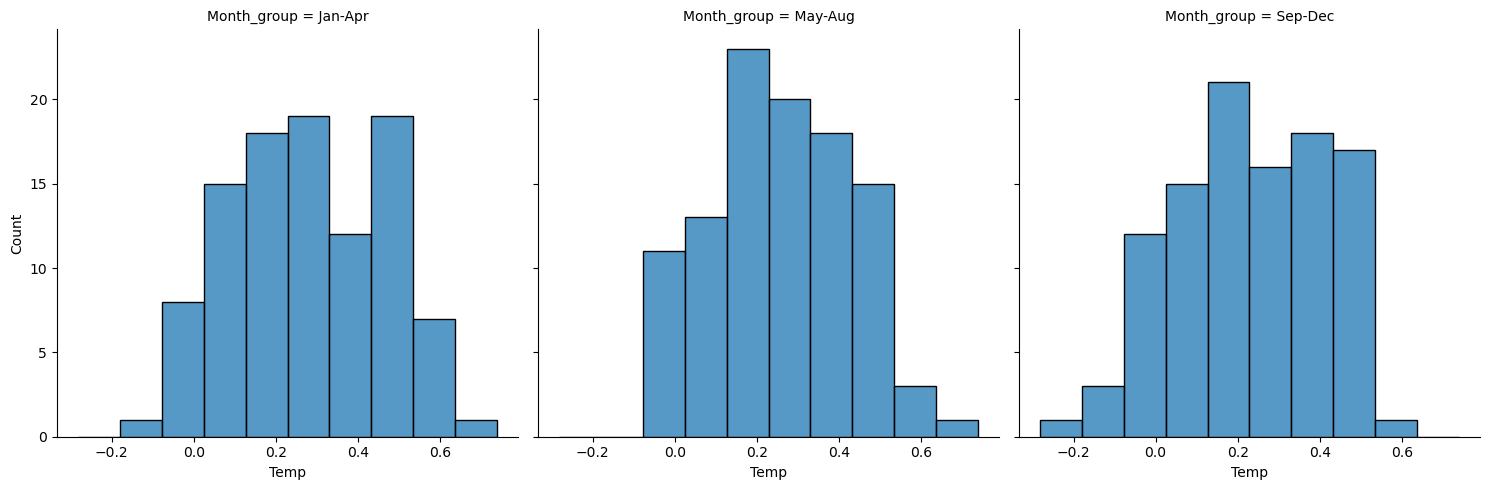

In [6]:
# Suppress benign FutureWarnings coming from seaborn's internal groupby calls
import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='seaborn')
# Group months into 3 broader periods (adjust boundaries to your definition of seasons/periods)
climate_df['Month_group'] = pd.cut(climate_df['Month'],
                                    bins=[0, 4, 8, 12],
                                    labels=['Jan-Apr', 'May-Aug', 'Sep-Dec'])

# Histograms of Temp with 10 bins, split into 3 month groups
sns.displot(data=climate_df,
            x='Temp',
            col='Month_group',
            col_wrap=3, bins=10)
# Show the plot
plt.show()

In [7]:
# Calculate the mean of Temp, grouped by month group
mean_temp_by_month_group = climate_df.groupby('Month_group', observed=True)['Temp'].mean()
# Print the result
print(mean_temp_by_month_group)

Month_group
Jan-Apr    0.278450
May-Aug    0.259981
Sep-Dec    0.232731
Name: Temp, dtype: float64


In [8]:
# Create the model, fit it
mdl_temp_vs_month_group = ols('Temp ~ Month_group', data=climate_df).fit()
# Print the parameters of the fitted model
print(mdl_temp_vs_month_group.params)

Intercept                 0.278450
Month_group[T.May-Aug]   -0.018469
Month_group[T.Sep-Dec]   -0.045719
dtype: float64


In [9]:
# Create the model, fit it
mdl_temp_vs_month_group = ols('Temp ~ Month_group + 0', data=climate_df).fit()
# Print the parameters of the fitted model
print(mdl_temp_vs_month_group.params)

Month_group[Jan-Apr]    0.278450
Month_group[May-Aug]    0.259981
Month_group[Sep-Dec]    0.232731
dtype: float64


Regrouping our climate data into three 4-month periods (Jan-Apr, May-Aug, Sep-Dec) and comparing mean Temp across them that captures the seasonal cycle in temperature over the year. The intercept-included model (Temp ~ Month_group) expresses this as one reference period's mean plus offsets for the other two, while the no-intercept version (Temp ~ Month_group + 0) gives each period's raw mean directly — and by the same least-squares logic covered earlier, those coefficients are mathematically guaranteed to match mean_temp_by_month_group exactly, since OLS minimizes squared error independently within each non-overlapping group. 

In [10]:
# Create explanatory_data — a range of CO2 values to predict Temp for
explanatory_data = pd.DataFrame({'CO2': np.arange(0, 11)})

# Use mdl_temp_vs_co2 to predict Temp for these CO2 values
Temp = mdl_temp_vs_co2.predict(explanatory_data)

# Create prediction_data by attaching predictions to the explanatory values
prediction_data = explanatory_data.assign(Temp=Temp)

# Print the result
print(prediction_data)

    CO2      Temp
0     0 -3.593140
1     1 -3.582541
2     2 -3.571942
3     3 -3.561343
4     4 -3.550744
5     5 -3.540144
6     6 -3.529545
7     7 -3.518946
8     8 -3.508347
9     9 -3.497748
10   10 -3.487148


In [11]:
# Fit model regressing CH4 on CO2
mdl_ch4_vs_co2 = ols("CH4 ~ CO2", data=climate_df).fit()
print(mdl_ch4_vs_co2.params)

Intercept    596.174675
CO2            3.176115
dtype: float64


In [12]:
# Create a realistic range of CO2 values based on actual data
explanatory_data = pd.DataFrame({'CO2': np.linspace(climate_df['CO2'].min(), climate_df['CO2'].max(), 11)})

# Predict CH4 for these CO2 values
CH4 = mdl_ch4_vs_co2.predict(explanatory_data)

# Attach predictions to the explanatory CO2 values
prediction_data = explanatory_data.assign(CH4=CH4)
print(prediction_data)

        CO2          CH4
0   340.170  1676.593620
1   345.003  1691.943782
2   349.836  1707.293944
3   354.669  1722.644107
4   359.502  1737.994269
5   364.335  1753.344432
6   369.168  1768.694594
7   374.001  1784.044757
8   378.834  1799.394919
9   383.667  1814.745082
10  388.500  1830.095244


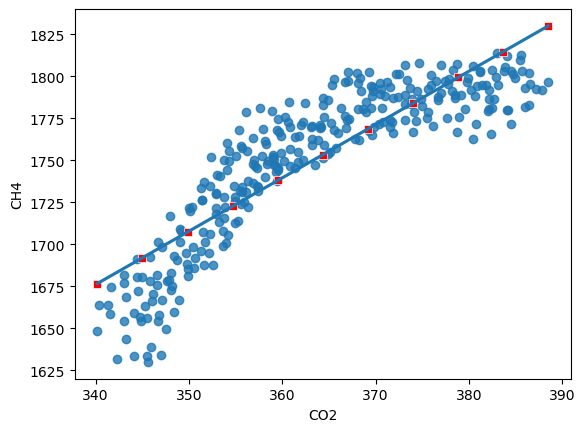

In [13]:
# Plot actual CH4 vs CO2 with regression line, then overlay predicted points in red
fig = plt.figure()
sns.regplot(x="CO2", y="CH4", data=climate_df, ci=None)
sns.scatterplot(x='CO2', y='CH4', data=prediction_data, color='red', marker='s')
plt.show()

In [14]:
# Define a DataFrame with impossible CO2 values
impossible = pd.DataFrame({'CO2': [-1, 2.5]})

# Use mdl_ch4_vs_co2 to predict CH4 for these impossible CO2 values
CH4 = mdl_ch4_vs_co2.predict(impossible)

# Create prediction_data by attaching predictions to the explanatory values
prediction_data = impossible.assign(CH4=CH4)

# Print the result
print(prediction_data)

   CO2         CH4
0 -1.0  592.998560
1  2.5  604.114962


Linear models don't know what is possible or not in real life. That means that they can give us predictions that don't make any sense when applied to our data. We need to understand what we our data means in order to determine whether a prediction is nonsense or not.

In [15]:
print(mdl_ch4_vs_co2.params)

Intercept    596.174675
CO2            3.176115
dtype: float64


In [16]:
print(mdl_ch4_vs_co2.fittedvalues)

0      1694.983324
1      1693.585833
2      1689.234556
3      1683.199938
4      1676.593620
          ...     
303    1816.279145
304    1812.912463
305    1812.594852
306    1816.215623
307    1820.757467
Length: 308, dtype: float64


In [17]:
print(mdl_ch4_vs_co2.resid)

0     -56.393324
1     -59.875833
2     -56.014556
3     -51.849938
4     -28.193620
         ...    
303   -36.399145
304   -17.832463
305     1.585148
306    -3.845623
307    -7.877467
Length: 308, dtype: float64


In [18]:
print(mdl_ch4_vs_co2.summary())

                            OLS Regression Results                            
Dep. Variable:                    CH4   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.760
Method:                 Least Squares   F-statistic:                     973.4
Date:                Fri, 10 Jul 2026   Prob (F-statistic):           4.58e-97
Time:                        17:25:56   Log-Likelihood:                -1395.8
No. Observations:                 308   AIC:                             2796.
Df Residuals:                     306   BIC:                             2803.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    596.1747     36.999     16.113      0.0

In [19]:
# Get the coefficients of mdl_ch4_vs_co2
coeffs = mdl_ch4_vs_co2.params

# Get the intercept and slope by their actual parameter names
intercept = coeffs.iloc[0]
slope = coeffs.iloc[1]

# Manually calculate the predictions
CH4 = intercept + slope * explanatory_data
print(CH4)

# Compare to the results from .predict()
print(CH4.assign(predictions_auto=mdl_ch4_vs_co2.predict(explanatory_data)))

            CO2
0   1676.593620
1   1691.943782
2   1707.293944
3   1722.644107
4   1737.994269
5   1753.344432
6   1768.694594
7   1784.044757
8   1799.394919
9   1814.745082
10  1830.095244
            CO2  predictions_auto
0   1676.593620       1676.593620
1   1691.943782       1691.943782
2   1707.293944       1707.293944
3   1722.644107       1722.644107
4   1737.994269       1737.994269
5   1753.344432       1753.344432
6   1768.694594       1768.694594
7   1784.044757       1784.044757
8   1799.394919       1799.394919
9   1814.745082       1814.745082
10  1830.095244       1830.095244


In [20]:
# Calculate mean Temp for each year
yearly_temp = climate_df.groupby('Year', observed=True)['Temp'].mean().reset_index()

# Shift the data to pair each year's Temp with the following year's Temp
yearly_temp['Temp_next_year'] = yearly_temp['Temp'].shift(-1)

# Drop the last row, since it has no "next year" to pair with
yearly_temp_paired = yearly_temp.dropna()

# Rename for clarity: this_year Temp vs next_year Temp
yearly_temp_paired = yearly_temp_paired.rename(columns={'Temp': 'Temp_this_year'})

print(yearly_temp_paired)

    Year  Temp_this_year  Temp_next_year
0   1983        0.136500       -0.018667
1   1984       -0.018667       -0.037083
2   1985       -0.037083        0.034083
3   1986        0.034083        0.177833
4   1987        0.177833        0.174500
5   1988        0.174500        0.109500
6   1989        0.109500        0.247500
7   1990        0.247500        0.203500
8   1991        0.203500        0.070917
9   1992        0.070917        0.105000
10  1993        0.105000        0.168583
11  1994        0.168583        0.269417
12  1995        0.269417        0.138667
13  1996        0.138667        0.348500
14  1997        0.348500        0.528667
15  1998        0.528667        0.303583
16  1999        0.303583        0.278083
17  2000        0.278083        0.406750
18  2001        0.406750        0.454500
19  2002        0.454500        0.466750
20  2003        0.466750        0.443667
21  2004        0.443667        0.474333
22  2005        0.474333        0.425000
23  2006        

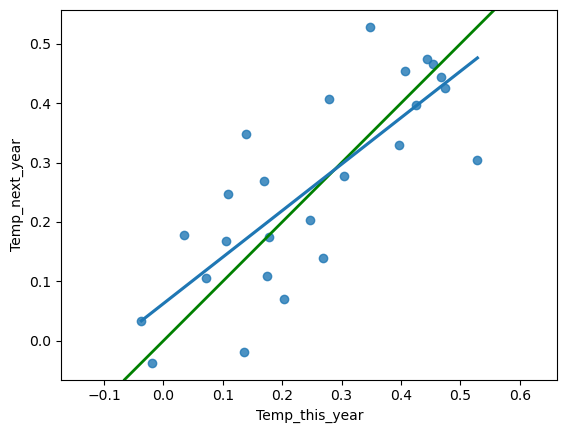

In [21]:
# Create a new figure, fig
fig = plt.figure()

# Plot the reference line: y = x (this year's Temp exactly predicts next year's Temp)
plt.axline(xy1=(yearly_temp_paired['Temp_this_year'].min(), yearly_temp_paired['Temp_this_year'].min()),
           slope=1, linewidth=2, color="green")

# Add scatter plot with linear regression trend line: this year's Temp vs next year's Temp
sns.regplot(data=yearly_temp_paired, x='Temp_this_year', y='Temp_next_year', ci=None)

# Set the axes so that distances along x and y look the same
plt.axis("equal")

# Show the plot
plt.show()

In [22]:
# Fit regression: does this year's Temp predict next year's Temp?
mdl_temp_yearly = ols("Temp_next_year ~ Temp_this_year", data=yearly_temp_paired).fit()

# Create a DataFrame with a few representative Temp_this_year values to predict from
explanatory_data = pd.DataFrame({"Temp_this_year": [-1, 0, 1]})

# Use mdl_temp_yearly to predict Temp_next_year for these values
print(mdl_temp_yearly.predict(explanatory_data))

0   -0.719677
1    0.062626
2    0.844930
dtype: float64


Predicting Temp_next_year at -1, 0, and 1 gives -0.72, 0.063, and 0.845 — each output sits closer to zero than a perfect 1-to-1 relationship would produce, meaning the slope is measurably below 1. That's the signature of mean reversion: unusually cold or warm years tend to be followed by years that drift back toward average, rather than repeating the extreme. Worth treating this as suggestive rather than solid, though — with only ~20 yearly points behind the fit, check mdl_temp_yearly.summary() (R² and the p-value on Temp_this_year) before leaning on it too hard.